In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [28]:
# Importando Forma de Pegar Arquivo
from google.colab import files

In [ ]:
# Importando Arquivo
uploaded = files.upload()

KeyboardInterrupt: 

In [29]:
# Carrega o CSV diário
df = pd.read_csv("XAU_1d_data.csv")

In [30]:
# Mostrar as 5 primeiras linhas
print(df.head())

                 Date;Open;High;Low;Close;Volume
0     2004.06.11 00:00;384;384.8;382.8;384.1;272
1  2004.06.14 00:00;384.3;385.8;381.8;382.8;1902
2  2004.06.15 00:00;382.8;388.8;381.1;388.6;1951
3  2004.06.16 00:00;387.1;389.8;382.6;383.8;2014
4    2004.06.17 00:00;383.6;389.3;383;387.6;1568


In [31]:
# Mostrar as colunas
print(df.columns)

Index(['Date;Open;High;Low;Close;Volume'], dtype='object')


In [32]:
# Mostrar informações do DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 1 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Date;Open;High;Low;Close;Volume  5391 non-null   object
dtypes: object(1)
memory usage: 42.2+ KB
None


# 🔥 Etapa 1 – Pré-processamento dos dados

**Passo 1: Converter a coluna de data para o tipo datetime e ordenar os dados**

In [33]:
# Carregue os dados com o separador correto
df = pd.read_csv('XAU_1d_data.csv', sep=';')

# Converter a coluna 'Data' em data e hora
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar os dados pela data (do mais antigo para o mais recente)
df = df.sort_values('Date').reset_index(drop=True)

# Mostrar as primeiras linhas para conferir
df.head()

,Date,Open,High,Low,Close,Volume
0,2004-06-11,384.0,384.8,382.8,384.1,272
1,2004-06-14,384.3,385.8,381.8,382.8,1902
2,2004-06-15,382.8,388.8,381.1,388.6,1951
3,2004-06-16,387.1,389.8,382.6,383.8,2014
4,2004-06-17,383.6,389.3,383.0,387.6,1568


**Passo 2: Verificar valores nulos e tratá-los**

In [34]:
# Verificar valores nulos
print(df.isnull().sum())

# Remover linhas com valores nulos (se existirem)
df = df.dropna()

# Conferir o resultado
print(df.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


Passo 3 (Opcional): Visualizar o preço de fechamento para garantir que tudo está **OK**

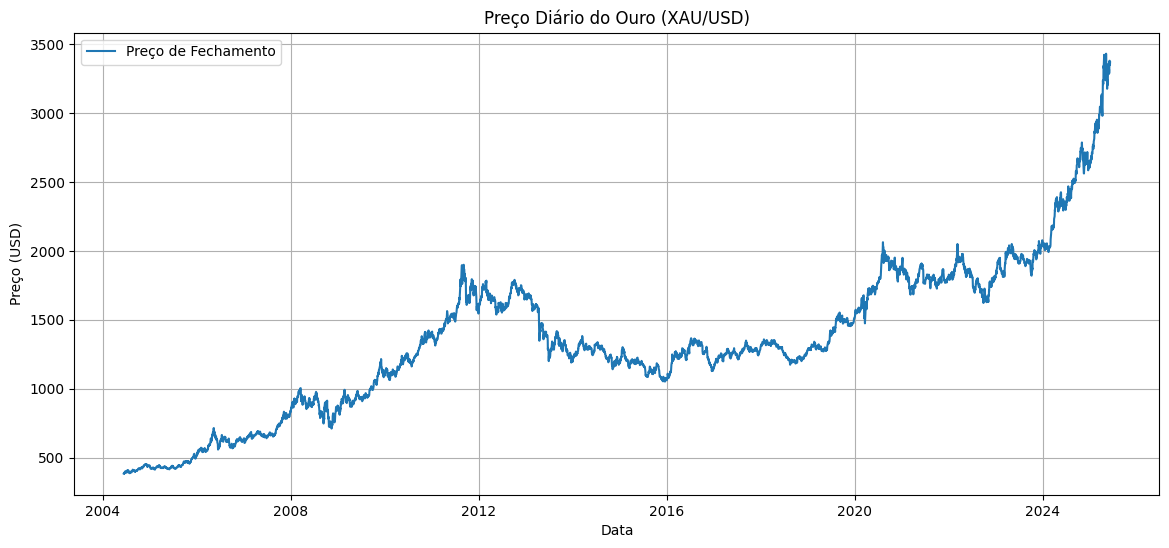

In [35]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close'], label='Preço de Fechamento')
plt.title('Preço Diário do Ouro (XAU/USD)')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.grid(True)
plt.legend()
plt.show()

# 🔥 Etapa 2 – Criação de variáveis preditoras

Passo 1: Criar colunas com os preços de fechamento dos últimos 5 dias (janela deslizante)**negrito**

In [36]:
# Definindo o tamanho da janela
window_size = 5

# Criando as colunas com os valores passados (t-5 até t-1)
for i in range(window_size, 0, -1):
    df[f'Close(t-{i})'] = df['Close'].shift(i)

# Coluna alvo: preço de fechamento do dia atual
df['Close(t)'] = df['Close']

# Remover as linhas com valores ausentes gerados pela função shift
df_model = df.dropna().reset_index(drop=True)

# Exibir as primeiras linhas do novo dataframe
df_model.head()


,Date,Open,High,Low,Close,Volume,Close(t-5),Close(t-4),Close(t-3),Close(t-2),Close(t-1),Close(t)
0,2004-06-18,388.6,395.8,385.8,394.3,2257,384.1,382.8,388.6,383.8,387.6,394.3
1,2004-06-21,394.3,396.8,392.1,393.1,1674,382.8,388.6,383.8,387.6,394.3,393.1
2,2004-06-22,392.8,396.3,392.3,394.1,1407,388.6,383.8,387.6,394.3,393.1,394.1
3,2004-06-23,394.0,396.6,392.3,395.6,1829,383.8,387.6,394.3,393.1,394.1,395.6
4,2004-06-24,394.0,402.8,393.1,401.1,1991,387.6,394.3,393.1,394.1,395.6,401.1


# 🔥 Etapa 3 – Separação dos Dados

**Passo 1: Definir variáveis de entrada (X) e alvo (y)**

In [ ]:
# Variáveis de entrada: colunas Close(t-5) até Close(t-1)
X = df_model[[f'Close(t-{i})' for i in range(5, 0, -1)]]

# Variável alvo: preço de fechamento do dia atual (Close(t))
y = df_model['Close(t)']


**Passo 2: Separar os dados em treino (80%) e teste (20%)**

In [ ]:
# Tamanho do conjunto de treino
tamanho_treino = int(len(df_model) * 0.8)

# Dividir os dados
X_train = X[:tamanho_treino]
X_test = X[tamanho_treino:]

y_train = y[:tamanho_treino]
y_test = y[tamanho_treino:]

# Verificar os tamanhos
print(f'Treino: {len(X_train)} amostras')
print(f'Teste: {len(X_test)} amostras')


Treino: 4308 amostras
Teste: 1078 amostras


# 🔥 Etapa 4 – Treinamento do Modelo

**Passo 1: Treinar um modelo de Regressão Linear**

In [ ]:
from sklearn.linear_model import LinearRegression

# Criar e treinar o modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)


LinearRegression()

**Passo 2: Fazer previsões com os dados de teste**

In [ ]:
# Fazer previsões no conjunto de teste
y_pred = modelo_lr.predict(X_test)

In [ ]:
# Verificar se o modelo foi treinado e se as previsões estão no formato esperado
print("Coeficientes do modelo:", modelo_lr.coef_)
print("Intercepto:", modelo_lr.intercept_)

# Verificar os primeiros valores previstos e reais
print("\nPrimeiros valores previstos:")
print(y_pred[:5])

print("\nPrimeiros valores reais:")
print(y_test.values[:5])


Coeficientes do modelo: [ 0.0246618  -0.01614204 -0.00472907 -0.01575183  1.01119884]
Intercepto: 1.206263981649954

Primeiros valores previstos:
[1728.61944786 1742.37366503 1736.80258357 1756.15312742 1742.79942146]

Primeiros valores reais:
[1743.06 1737.57 1756.14 1743.46 1732.34]


# 🔥 Etapa 5 – Avaliação do Modelo

Vamos usar as seguintes métricas:

**MAE (Erro Absoluto Médio) →** mede o erro médio absoluto entre as previsões e os valores reais.

**RMSE (Raiz do Erro Quadrático Médio) →** penaliza mais os erros grandes.

**R² (Coeficiente de Determinação)** → mede o quanto o modelo explica da variabilidade dos dados. Varia de -∞ até 1. Quanto mais próximo de 1, melhor.

**Passo 1: Calcular as métricas**

In [ ]:
# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R²
r2 = r2_score(y_test, y_pred)

# Exibir resultados
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


MAE: 15.12
RMSE: 21.47
R²: 0.9974


**Passo 2: Visualizar previsões vs valores reais**

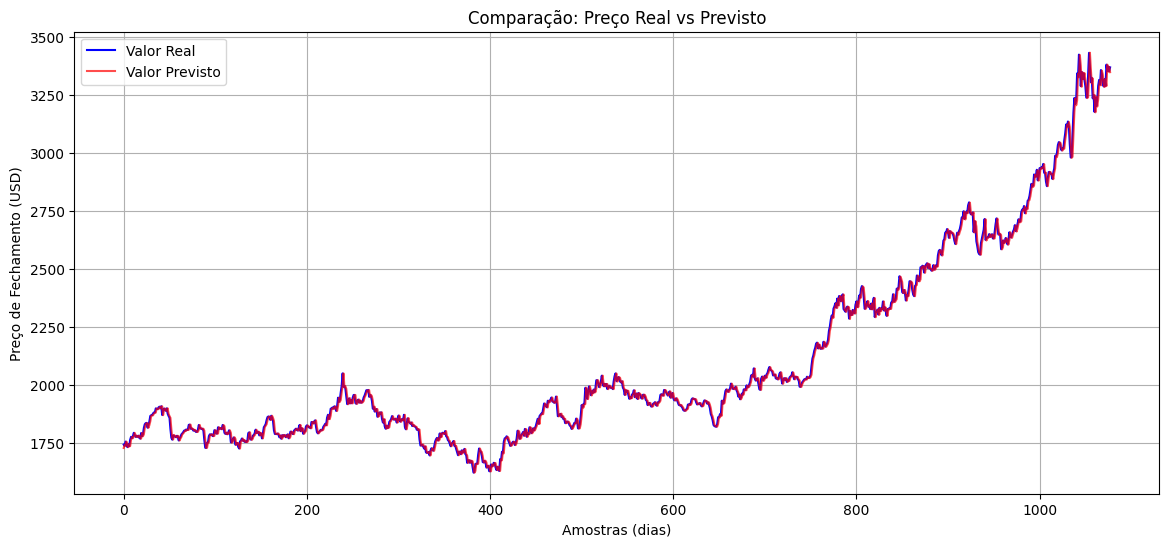

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label='Valor Real', color='blue')
plt.plot(y_pred, label='Valor Previsto', color='red', alpha=0.7)
plt.title('Comparação: Preço Real vs Previsto')
plt.xlabel('Amostras (dias)')
plt.ylabel('Preço de Fechamento (USD)')
plt.legend()
plt.grid(True)
plt.show()


| Métrica | Valor  | Interpretação                                                                                          |
|---------|--------|------------------------------------------------------------------------------------------------------|
| MAE     | 15.12  | O erro médio entre o valor previsto e o real é de ~15 dólares, o que é baixo considerando que o preço do ouro gira em torno de 1700–2000 USD. |
| RMSE    | 21.47  | Erros maiores são um pouco penalizados, mas ainda assim o valor está baixo.                           |
| R²      | 0.9974 ✅ | Isso significa que 99,74% da variação nos preços está sendo explicada pelo modelo — é muito bom, especialmente para uma Regressão Linear simples! |


# 🔥 Etapa 6 – Visualização e Interpretação

**Passo 1: Gráfico de Linha com Preço Real vs Previsto**

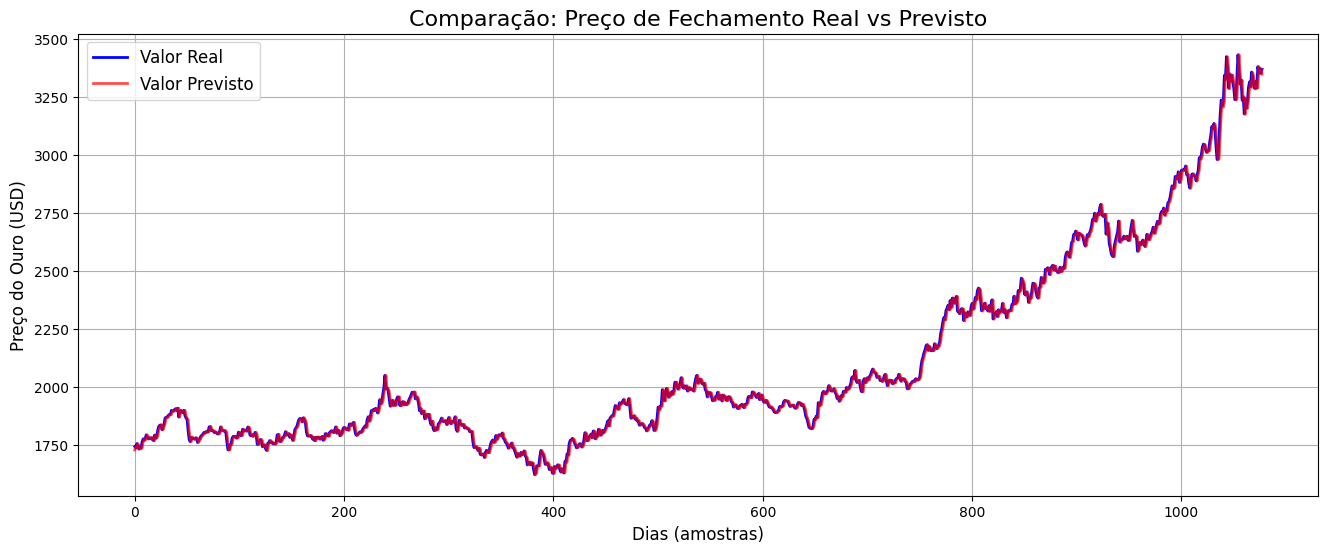

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(y_test.values, label='Valor Real', color='blue', linewidth=2)
plt.plot(y_pred, label='Valor Previsto', color='red', linewidth=2, alpha=0.7)
plt.title('Comparação: Preço de Fechamento Real vs Previsto', fontsize=16)
plt.xlabel('Dias (amostras)', fontsize=12)
plt.ylabel('Preço do Ouro (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


**Passo 2: Avaliação Final**

O modelo de Regressão Linear foi capaz de prever com alta precisão os preços de fechamento do ouro com base nos últimos 5 dias.  
As métricas obtidas (**MAE = 15.12**, **RMSE = 21.47**, **R² = 0.9974**) indicam um desempenho muito bom.  
O gráfico mostra que o modelo acompanha de forma fiel a tendência do preço real, mesmo durante períodos de alta volatilidade.




## 🔥 Etapa 7 – Previsão do próximo dia (1 dia à frente)

Com o modelo treinado, podemos prever o preço de fechamento do ouro para o próximo dia com base nos últimos 5 dias reais.

A previsão será exibida em:
- 💰 Onça troy (oz t)
- ⚖️ Quilograma (kg)
- 🧪 Grama (g)



In [ ]:
# Obter os últimos 5 preços reais
ultimos_5_dias = df['Close'].iloc[-5:].values

# Formatar para entrada do modelo
entrada_amanha = ultimos_5_dias.reshape(1, -1)

# Prever o preço de 1 onça troy
previsao_oz = modelo_lr.predict(entrada_amanha)[0]

# Conversões
previsao_kg = previsao_oz * 32.1507          # 1 kg = 32.1507 onças troy
previsao_g = previsao_oz / 31.1035           # 1 oz t = 31.1035 gramas

# Exibir resultados
print(f"📅 Previsão do preço do ouro para amanhã:")
print(f"💰 Por onça troy (oz t): {previsao_oz:.2f} USD")
print(f"⚖️  Por quilograma (kg): {previsao_kg:.2f} USD")
print(f"🧪 Por grama (g):        {previsao_g:.2f} USD")



📅 Previsão do preço do ouro para amanhã:
💰 Por onça troy (oz t): 3368.38 USD
⚖️  Por quilograma (kg): 108295.68 USD
🧪 Por grama (g):        108.30 USD


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# ⚠️ Aviso!

Este é o meu primeiro projeto na área de análise de dados e machine learning, desenvolvido como um exercício prático para aplicar conceitos fundamentais de manipulação, visualização e modelagem de dados.

Gostaria de relatar alguns pontos importantes sobre a metodologia e os dados utilizados:

1.  **Fonte dos Dados:** Os dados históricos do preço do ouro (XAU/USD) foram obtidos a partir de um dataset público.

2.  **Limitação de Atualização:** É fundamental destacar que este arquivo é uma "fotografia" estática dos dados e **não é atualizado diariamente**. A versão utilizada reflete os dados até a data da sua última publicação pelo autor.

3.  **Processo Manual:** Como consequência, para incorporar cotações mais recentes à análise, **é necessário um processo manual**. Este processo consiste em encontrar uma versão mais nova do arquivo de dados e substituí-lo manualmente no ambiente do projeto.

Essa limitação implica que qualquer análise ou previsão gerada por este notebook reflete o estado do mercado na data da última atualização do arquivo, e não necessariamente no dia corrente.

O foco deste trabalho foi o aprendizado do processo de análise e modelagem, e a automação do pipeline de dados seria um excelente próximo passo para uma versão futura deste projeto.


# https://www.kaggle.com/datasets/novandraanugrah/xauusd-gold-price-historical-data-2004present